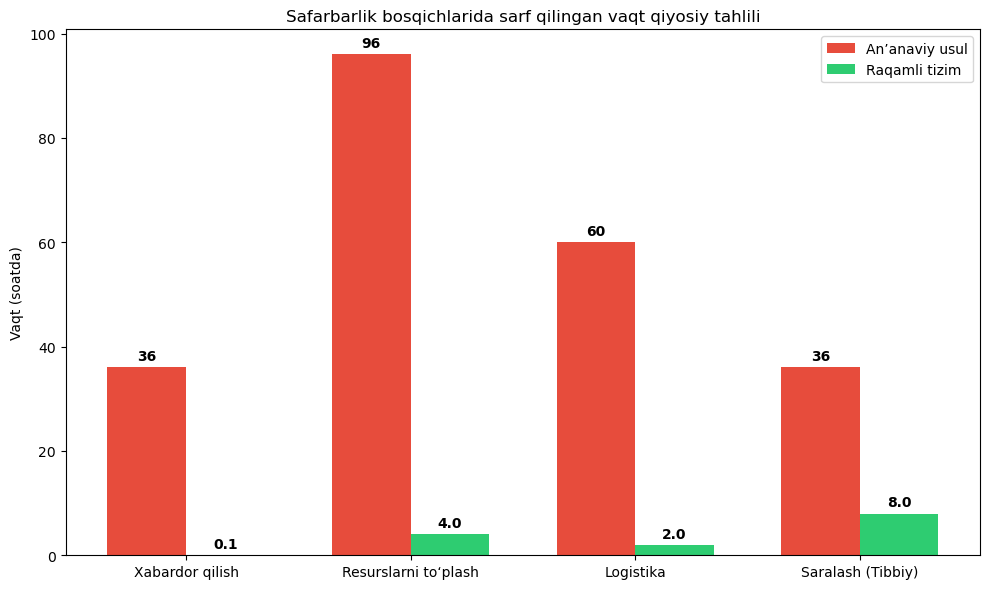

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Ma'lumotlar (Sarf qilingan vaqt - soatlarda)
stages = [
    'Xabardor qilish', 
    'Resurslarni to‘plash', 
    'Logistika', 
    'Saralash (Tibbiy)'
]
traditional_time = [36, 96, 60, 36]  # An'anaviy usul
digital_time = [0.1, 4, 2, 8]        # Raqamli tizim

x = np.arange(len(stages))  # Bosqichlar o'rni
width = 0.35                # Ustunlar kengligi

fig, ax = plt.subplots(figsize=(10, 6))

# Ustunlarni chizish
rects1 = ax.bar(x - width/2, traditional_time, width, label='An’anaviy usul', color='#e74c3c')
rects2 = ax.bar(x + width/2, digital_time, width, label='Raqamli tizim', color='#2ecc71')

# Grafikni bezash
ax.set_ylabel('Vaqt (soatda)')
ax.set_title('Safarbarlik bosqichlarida sarf qilingan vaqt qiyosiy tahlili')
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.legend()

# Ustunlar ustiga qiymatlarni yozib chiqish funksiyasi
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

# Grafikni saqlash yoki ko'rsatish
plt.show()

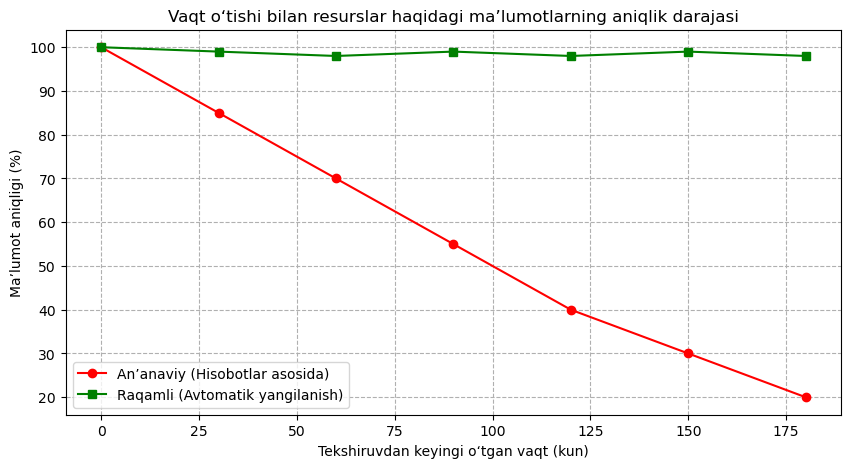

In [2]:
import matplotlib.pyplot as plt

# Ma'lumotning aniqlik darajasi (vaqt o'tishi bilan)
days = [0, 30, 60, 90, 120, 150, 180] # Kunlar
accuracy_manual = [100, 85, 70, 55, 40, 30, 20] # An'anaviy tizimda
accuracy_digital = [100, 99, 98, 99, 98, 99, 98] # Raqamli (real-time) tizimda

plt.figure(figsize=(10, 5))
plt.plot(days, accuracy_manual, 'r-o', label='An’anaviy (Hisobotlar asosida)')
plt.plot(days, accuracy_digital, 'g-s', label='Raqamli (Avtomatik yangilanish)')

plt.title('Vaqt o‘tishi bilan resurslar haqidagi ma’lumotlarning aniqlik darajasi')
plt.xlabel('Tekshiruvdan keyingi o‘tgan vaqt (kun)')
plt.ylabel('Ma’lumot aniqligi (%)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()


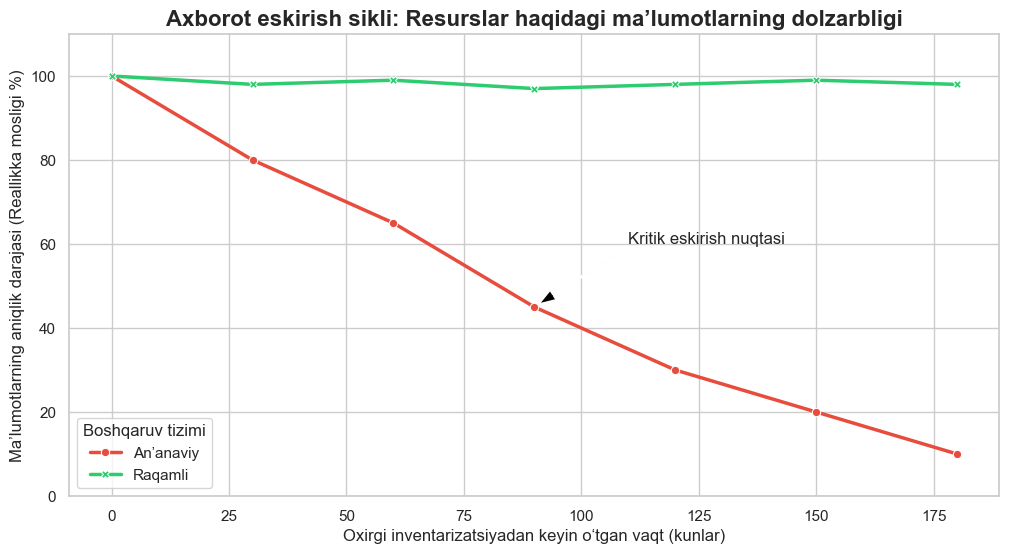

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ma'lumotlarni tayyorlash
data = {
    'Vaqt (Kunlar)': [0, 30, 60, 90, 120, 150, 180, 0, 30, 60, 90, 120, 150, 180],
    'Aniqlik darajasi (%)': [100, 80, 65, 45, 30, 20, 10, 100, 98, 99, 97, 98, 99, 98],
    'Tizim turi': ['An’anaviy', 'An’anaviy', 'An’anaviy', 'An’anaviy', 'An’anaviy', 'An’anaviy', 'An’anaviy', 
                   'Raqamli', 'Raqamli', 'Raqamli', 'Raqamli', 'Raqamli', 'Raqamli', 'Raqamli']
}

df = pd.DataFrame(data)

# Seaborn stilini sozlash
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Grafikni chizish
line_plot = sns.lineplot(data=df, x='Vaqt (Kunlar)', y='Aniqlik darajasi (%)', 
                         hue='Tizim turi', style='Tizim turi', 
                         markers=True, dashes=False, palette=['#e74c3c', '#2ecc71'], linewidth=2.5)

# Grafik bezaklari
plt.title('Axborot eskirish sikli: Resurslar haqidagi ma’lumotlarning dolzarbligi', fontsize=16, fontweight='bold')
plt.xlabel('Oxirgi inventarizatsiyadan keyin o‘tgan vaqt (kunlar)', fontsize=12)
plt.ylabel('Ma’lumotlarning aniqlik darajasi (Reallikka mosligi %)', fontsize=12)
plt.ylim(0, 110)

# Muhim nuqtaga izoh qo'shish (An'anaviy tizim inqirozi)
plt.annotate('Kritik eskirish nuqtasi', xy=(90, 45), xytext=(110, 60),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.legend(title='Boshqaruv tizimi')
plt.show()

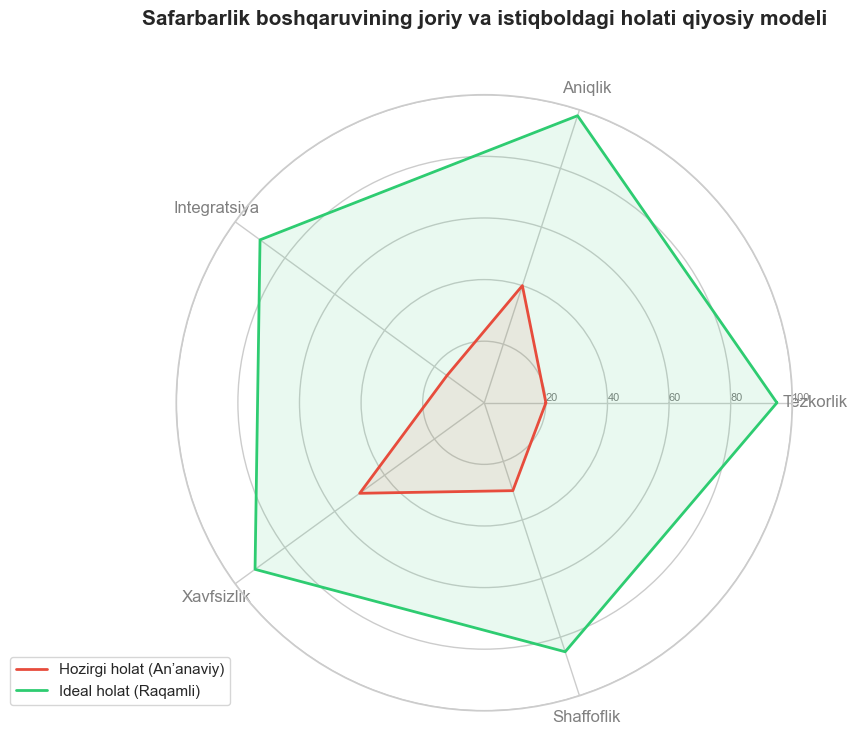

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi

# 1. Ma'lumotlarni shakllantirish
# Mezonlar: Tezkorlik, Aniqlik, Integratsiya, Xavfsizlik, Shaffoflik
df = pd.DataFrame({
    'group': ['Hozirgi holat (An’anaviy)', 'Ideal holat (Raqamli)'],
    'Tezkorlik': [20, 95],
    'Aniqlik': [40, 98],
    'Integratsiya': [15, 90],
    'Xavfsizlik': [50, 92],
    'Shaffoflik': [30, 85]
})

# 2. Radar chart uchun koordinatalarni tayyorlash
categories = list(df)[1:]
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(10, 8))
ax = plt.subplot(111, polar=True)

# Birinchi chiziqni chizish (Hozirgi holat)
values = df.loc[0].drop('group').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Hozirgi holat (An’anaviy)", color='#e74c3c')
ax.fill(angles, values, '#e74c3c', alpha=0.1)

# Ikkinchi chiziqni chizish (Ideal holat)
values = df.loc[1].drop('group').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Ideal holat (Raqamli)", color='#2ecc71')
ax.fill(angles, values, '#2ecc71', alpha=0.1)

# Bezaklar
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60, 80, 100], ["20", "40", "60", "80", "100"], color="grey", size=8)
plt.ylim(0, 100)

plt.title('Safarbarlik boshqaruvining joriy va istiqboldagi holati qiyosiy modeli', size=15, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

plt.show()

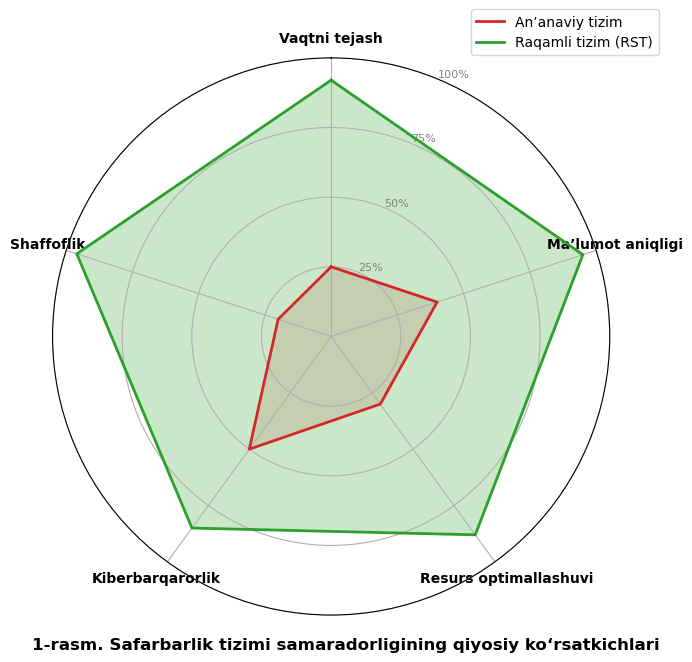

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ma'lumotlar
labels = np.array([
    'Vaqtni tejash', 'Ma’lumot aniqligi', 
    'Resurs optimallashuvi', 'Kiberbarqarorlik', 'Shaffoflik'
])

traditional = np.array([25, 40, 30, 50, 20]) 
digital = np.array([92, 95, 88, 85, 96]) 

num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Grafikni yopish
traditional = np.concatenate((traditional, [traditional[0]]))
digital = np.concatenate((digital, [digital[0]]))
angles += angles[:1]

# 2. Grafik chizish
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Shkalani va yo'nalishni sozlash
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# An'anaviy tizim
ax.plot(angles, traditional, color='#d62728', linewidth=2, label='An’anaviy tizim')
ax.fill(angles, traditional, color='#d62728', alpha=0.15)

# Raqamli tizim
ax.plot(angles, digital, color='#2ca02c', linewidth=2, label='Raqamli tizim (RST)')
ax.fill(angles, digital, color='#2ca02c', alpha=0.25)

# O'qlarni bezash
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_rgrids([25, 50, 75, 100], labels=['25%', '50%', '75%', '100%'], color="grey", size=8)

# Legendni joylashuvi (Tepadagi bo'sh joyga)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

# Sarlavhani (Title) pastga qo'yish
plt.figtext(0.5, 0.02, "1-rasm. Safarbarlik tizimi samaradorligining qiyosiy ko‘rsatkichlari", 
            wrap=True, horizontalalignment='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

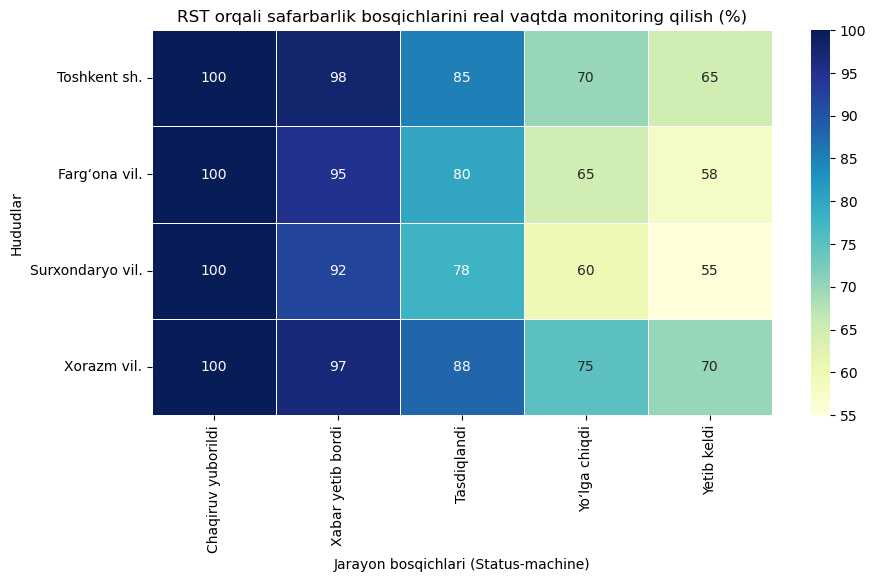

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ma'lumotlar (Namuna: hududlar bo'yicha chaqiruv holati %)
data = {
    'Chaqiruv yuborildi': [100, 100, 100, 100],
    'Xabar yetib bordi': [98, 95, 92, 97],
    'Tasdiqlandi': [85, 80, 78, 88],
    'Yo‘lga chiqdi': [70, 65, 60, 75],
    'Yetib keldi': [65, 58, 55, 70]
}
regions = ['Toshkent sh.', 'Farg‘ona vil.', 'Surxondaryo vil.', 'Xorazm vil.']
df = pd.DataFrame(data, index=regions)

plt.figure(figsize=(10, 5))
sns.heatmap(df, annot=True, cmap="YlGnBu", fmt='g', linewidths=.5)
plt.title("RST orqali safarbarlik bosqichlarini real vaqtda monitoring qilish (%)")
plt.xlabel("Jarayon bosqichlari (Status-machine)")
plt.ylabel("Hududlar")
plt.show()

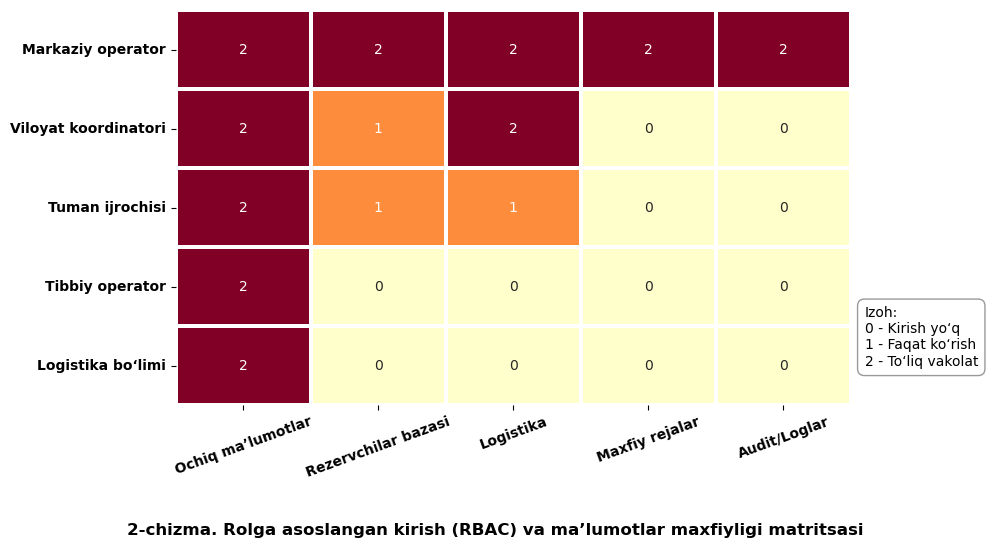

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Ma'lumotlar: 0-Kirish yo'q, 1-Faqat ko'rish, 2-To'liq vakolat
data = {
    'Ochiq ma’lumotlar': [2, 2, 2, 2, 2],
    'Rezervchilar bazasi': [2, 1, 1, 0, 0],
    'Logistika': [2, 2, 1, 0, 0],
    'Maxfiy rejalar': [2, 0, 0, 0, 0],
    'Audit/Loglar': [2, 0, 0, 0, 0]
}

roles = [
    'Markaziy operator', 'Viloyat koordinatori', 
    'Tuman ijrochisi', 'Tibbiy operator', 'Logistika bo‘limi'
]

df = pd.DataFrame(data, index=roles)

# 2. Grafik chizish
plt.figure(figsize=(10, 5))
# Heatmapni chizish, cbar=False (shkala o'ngda chiqmasligi uchun)
sns.heatmap(df, annot=True, cmap="YlOrRd", linewidths=1.5, linecolor='white', cbar=False)

# Rollar va ustun nomlarini qalin qilish
plt.xticks(fontweight='bold', rotation=20)
plt.yticks(fontweight='bold')

# Legendni chizmadan butunlay tashqariga, o'ng past burchakka chiqarish
plt.annotate('Izoh:\n0 - Kirish yo‘q\n1 - Faqat ko‘rish\n2 - To‘liq vakolat', 
             xy=(1.02, 0.1), xycoords='axes fraction', fontsize=10, 
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8))

# Sarlavhani (Title) pastga qo'yish
plt.figtext(0.5, -0.08, "2-chizma. Rolga asoslangan kirish (RBAC) va ma’lumotlar maxfiyligi matritsasi", 
            wrap=True, horizontalalignment='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()